In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import gudhi as gd

In [74]:
# fire station data
all_stations = gpd.read_file('Data/all_stations.geojson')

# LA County Census Tracts and SVI 
svi_tracts = gpd.read_file('Data/svi_tracts.geojson')

In [76]:
# reproject data to distance based CRS
all_stations = all_stations.to_crs('EPSG:2229')
svi_tracts = svi_tracts.to_crs('EPSG:2229')

In [77]:
# compute centroids
svi_tracts['centroid'] = svi_tracts['geometry'].centroid

In [79]:
# get fire station  and centroid coordinates
station_coords = all_stations.geometry.get_coordinates().to_numpy()
centroid_coords = svi_tracts['centroid'].get_coordinates().to_numpy()

In [53]:
skeleton1 = gd.RipsComplex(points = station_coords, max_edge_length = 26400) # 5 miles

In [54]:
Rips_simplex_tree1 = skeleton1.create_simplex_tree(max_dimension = 2) 

In [55]:
diag1 = Rips_simplex_tree1.persistence()

<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

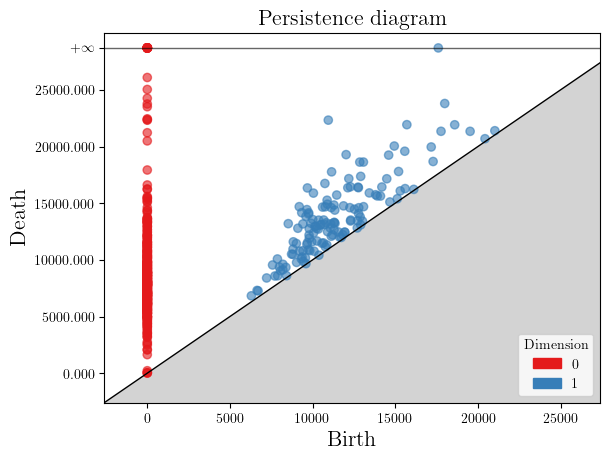

In [56]:
gd.plot_persistence_diagram(diag1)

<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

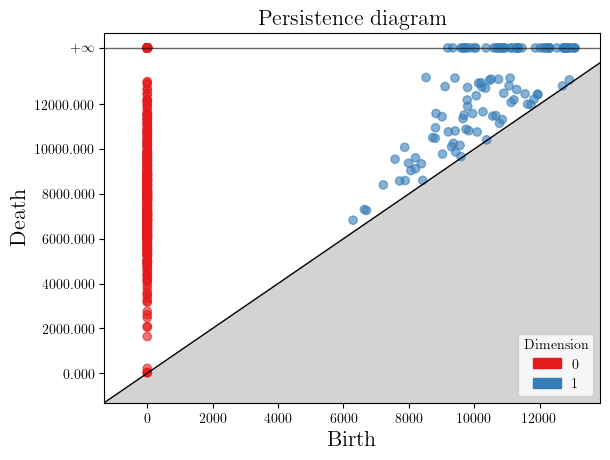

In [57]:
skeleton2 = gd.RipsComplex(points = station_coords, max_edge_length = 13200) # 2.5 miles
Rips_simplex_tree2 = skeleton2.create_simplex_tree(max_dimension = 2)
diag2 = Rips_simplex_tree2.persistence()
gd.plot_persistence_diagram(diag2)

In [80]:
# combine coordinates and
all_coords = np.vstack([station_coords, centroid_coords])
skeleton = gd.RipsComplex(points = all_coords, max_edge_length = 26400) # 5 miles

In [81]:
Rips_simplex_tree = skeleton.create_simplex_tree(max_dimension = 2) 

In [82]:
diag = Rips_simplex_tree.persistence()

In [93]:
diag

[(1, (16967.12692755171, inf)),
 (1, (24691.147465946717, inf)),
 (1, (6859.775256326038, 16539.242696143112)),
 (1, (4467.757966731949, 10920.184990805621)),
 (1, (6291.386153774154, 12635.831519010428)),
 (1, (13889.741810597667, 19993.425536613384)),
 (1, (6579.951539422495, 12652.34220012763)),
 (1, (7450.207528504832, 13257.058847188746)),
 (1, (4107.659041650393, 9864.314791978402)),
 (1, (14014.949736658913, 19537.397360111427)),
 (1, (3907.783259235655, 8756.027694766153)),
 (1, (6768.425441264743, 11584.440490440253)),
 (1, (7367.910652730427, 12096.746908135556)),
 (1, (13163.309243129244, 17760.940451553884)),
 (1, (4715.4658176109415, 9278.495963036177)),
 (1, (3351.64235988853, 7900.754785861305)),
 (1, (7053.733398153682, 11498.582772040498)),
 (1, (7497.576340831342, 11862.000692053178)),
 (1, (4172.725294264508, 8385.933600960438)),
 (1, (6030.389928944882, 10091.73918851528)),
 (1, (9745.752818961717, 13769.35634640872)),
 (1, (3528.2738719748427, 7485.289045062439)),


In [108]:
h1_loops = [i for i in diag if i[0] == 1]

In [109]:
h1_loops

[(1, (16967.12692755171, inf)),
 (1, (24691.147465946717, inf)),
 (1, (6859.775256326038, 16539.242696143112)),
 (1, (4467.757966731949, 10920.184990805621)),
 (1, (6291.386153774154, 12635.831519010428)),
 (1, (13889.741810597667, 19993.425536613384)),
 (1, (6579.951539422495, 12652.34220012763)),
 (1, (7450.207528504832, 13257.058847188746)),
 (1, (4107.659041650393, 9864.314791978402)),
 (1, (14014.949736658913, 19537.397360111427)),
 (1, (3907.783259235655, 8756.027694766153)),
 (1, (6768.425441264743, 11584.440490440253)),
 (1, (7367.910652730427, 12096.746908135556)),
 (1, (13163.309243129244, 17760.940451553884)),
 (1, (4715.4658176109415, 9278.495963036177)),
 (1, (3351.64235988853, 7900.754785861305)),
 (1, (7053.733398153682, 11498.582772040498)),
 (1, (7497.576340831342, 11862.000692053178)),
 (1, (4172.725294264508, 8385.933600960438)),
 (1, (6030.389928944882, 10091.73918851528)),
 (1, (9745.752818961717, 13769.35634640872)),
 (1, (3528.2738719748427, 7485.289045062439)),


In [110]:
# Define safe persistence value even when death is inf
def persistence(pair):
    birth, death = pair[1]
    return float('inf') if np.isinf(death) else death - birth

h1_loops_sorted = sorted(h1_loops, key=persistence, reverse=True)

In [113]:
dim, (birth, death) = h1_loops[2]
print(f"Using H1 loop with birth: {birth:.2f}, death: {death:.2f}")

Using H1 loop with birth: 6859.78, death: 16539.24


In [114]:
edges = []
for simplex, filt_val in Rips_simplex_tree.get_filtration():
    if len(simplex) == 2 and filt_val <= birth:
        i, j = simplex
        edges.append((i, j))

In [105]:
birth_threshold = top_loops[0][1][0] + 100
top_loops[0][1][0]

16967.12692755171

In [ ]:
edges = []
birth_threshold = top_loops[0][1][0] + 100  # slight buffer over birth
for simplex, filtration_value in st.get_filtration():
    if len(simplex) == 2 and filtration_value <= birth_threshold:
        pt1, pt2 = combined_coords[simplex[0]], combined_coords[simplex[1]]
        edges.append((pt1, pt2))

In [63]:
diag1

[(1, (17603.721463160553, inf)),
 (1, (10949.43315388108, 22328.56349649339)),
 (1, (12027.27611016944, 19285.528351965782)),
 (1, (9686.309855477079, 16344.839879859699)),
 (1, (11149.465881905602, 17765.860035230697)),
 (1, (15702.57311208819, 21928.555826266165)),
 (1, (10744.69752097363, 16740.761766762596)),
 (1, (10049.857135832795, 15890.563964627514)),
 (1, (17993.7714954061, 23796.6725211426)),
 (1, (12854.149284670866, 18626.86252396266)),
 (1, (13075.203113592988, 18629.84885530857)),
 (1, (9192.874719880383, 14693.964769592805)),
 (1, (14941.177061411468, 20043.39275834771)),
 (1, (12191.211872074331, 17165.513204560975)),
 (1, (9343.582005852373, 14163.87073841894)),
 (1, (9656.311777746836, 14433.906088482725)),
 (1, (8528.36696858716, 13192.832594393341)),
 (1, (14600.901080819673, 19243.20139940518)),
 (1, (12909.891213544804, 17367.050564421967)),
 (1, (9764.308180528904, 14152.22478107344)),
 (1, (10877.057250579925, 15262.407577125132)),
 (1, (9756.033828708381, 1404

In [65]:
# H0 features (connected components)
h0 = [p for p in diag1 if p[0] == 0]

In [68]:
# Get birth times (initial distance where point joins cluster)
births = np.array([b[0] for a, b in h0])

In [70]:
# Since the VR complex builds from a point cloud, ordering matches
all_stations['birth_scale'] = births[:len(all_stations)]

NameError: name 'fire_stations' is not defined

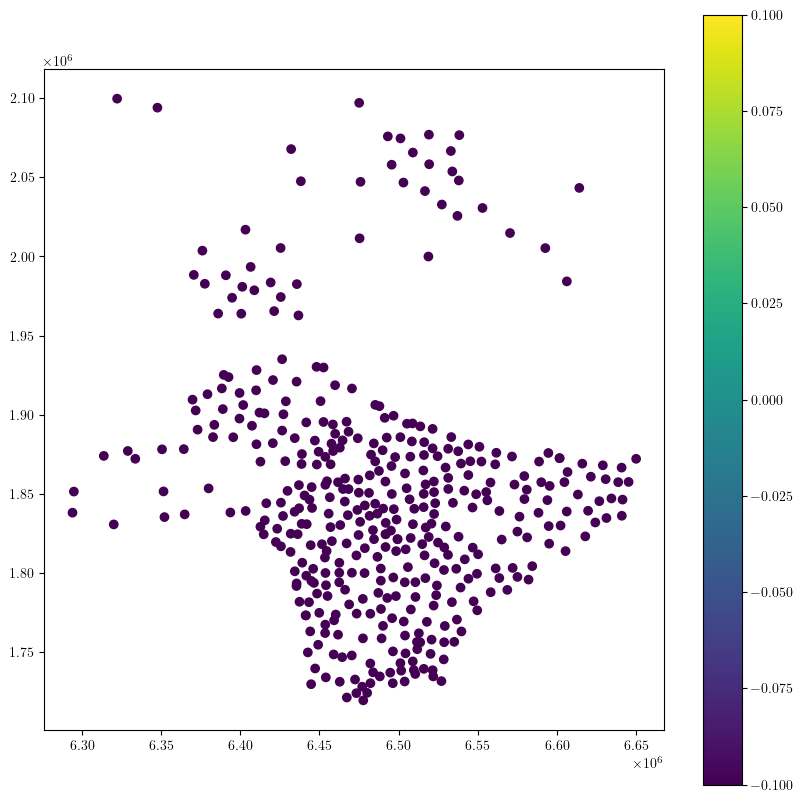

In [73]:
fig, ax = plt.subplots(figsize=(10, 10))
all_stations.plot(column='birth_scale', cmap='viridis', legend=True, ax=ax)
fire_stations.plot(ax=ax, color='red', markersize=20, label='Fire Stations')

In [60]:
edges = []
birth_threshold = top_loops[0][1][0] + 100  # slight buffer over birth
for simplex, filtration_value in Rips_simplex_tree1.get_filtration():
    if len(simplex) == 2 and filtration_value <= birth_threshold:
        pt1, pt2 = station_coords[simplex[0]], station_coords[simplex[1]]
        edges.append((pt1, pt2))

In [62]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot base points
ax.scatter(*station_coords.T, color='black', s=10, label='Stations')

# Plot loop edges
for pt1, pt2 in edges:
    ax.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], color='red', alpha=0.6)

plt.title("Approximate Persistent H₁ Loop")
ax.set_aspect('equal')
plt.legend()
plt.show()

RuntimeError: latex was not able to process the following string:
b'Approximate Persistent H\\u2081 Loop'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpd534o6rx 06d0b24c5890097505a48a853107a7b6.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.26 (MiKTeX 24.4) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(06d0b24c5890097505a48a853107a7b6.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(C:\Users\giova\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(C:\Users\giova\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))
(C:\Users\giova\AppData\Local\Programs\MiKTeX\tex/latex/type1cm\type1cm.sty)
(C:\Users\giova\AppData\Local\Programs\MiKTeX\tex/latex/cm-super\type1ec.sty
(C:\Users\giova\AppData\Local\Programs\MiKTeX\tex/latex/base\t1cmr.fd))
(C:\Users\giova\A

<Figure size 1000x1000 with 1 Axes>